# Titanic Survival Prediction using Logistic Regression

**Hands-On Lab**

In this lab you will build, tune, and evaluate a logistic regression classifier that
predicts passenger survival on the Titanic. You will practice:

- Data cleaning & preprocessing
- Exploratory Data Analysis (EDA)
- Logistic Regression with multiple features
- Decision boundaries
- Polynomial features
- Regularization (underfitting vs overfitting)
- Full classification evaluation (Accuracy, Precision, Recall, F1, ROC-AUC)
- Learning curves
- Probability threshold tuning
- Comparing classification algorithms
- Model persistence & inference

> This lab assumes you already understand the theory of Classification, Logistic
> Regression, the Sigmoid function, Decision Boundaries, the Logistic Cost Function,
> Gradient Descent, Multiple Features, Vectorization, Feature Scaling, Feature
> Engineering, Polynomial Regression, Regularization, and Underfitting vs Overfitting.
> We focus here on **implementation**.

## 2. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, classification_report, confusion_matrix,
    ConfusionMatrixDisplay,
)

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 3. Load Dataset

In [2]:
df = pd.read_csv("data/Titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [4]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (891, 12)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


## 4. Quick Data Quality Check

In [7]:
missing_table = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().sum() / len(df) * 100).round(2),
})
missing_table = missing_table[missing_table["Missing Count"] > 0].sort_values(
    "Missing Count", ascending=False
)
print(f"Duplicate rows: {df.duplicated().sum()}")
print()
print("Data types:")
print(df.dtypes)
print()
missing_table

Duplicate rows: 0

Data types:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object



,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Observation:** `Cabin` is missing for most passengers (~77%), `Age` is missing
for about 20%, and `Embarked` is missing for only 2 rows. There are no duplicate rows.
This tells us `Cabin` isn't reliably usable, `Age` needs imputation rather than
dropping, and `Embarked`'s two missing rows can be safely filled with the mode.

## 5. Data Preprocessing

Steps performed below, in order:

1. **Impute `Age`** with the median (robust to the skew/outliers typical of age data).
2. **Impute `Embarked`** with the mode (only 2 missing values, categorical).
3. **Drop `PassengerId`, `Name`, `Ticket`, `Cabin`** — identifiers/free text with no
   direct predictive value as-is, and `Cabin` is too sparse to impute reliably.
4. **Encode `Sex` and `Embarked`** with one-hot encoding (`drop_first=True`) so the
   model receives numeric input without implying a false ordering between
   categories.

In [8]:
df_clean = df.copy()

# 1. Impute Age with median
df_clean["Age"] = df_clean["Age"].fillna(df_clean["Age"].median())

# 2. Impute Embarked with mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

# 3. Drop non-predictive / too-sparse columns
df_clean = df_clean.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# 4. One-hot encode categorical columns
df_clean = pd.get_dummies(df_clean, columns=["Sex", "Embarked"], drop_first=True)

print(f"Processed dataset shape: {df_clean.shape}")
df_clean.head()

Processed dataset shape: (891, 9)


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [9]:
df_clean.isna().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

**Observation:** After preprocessing there are zero missing values, and `Sex`/
`Embarked` are now numeric (`Sex_male`, `Embarked_Q`, `Embarked_S`), ready for a linear
model.

## 6. Exploratory Data Analysis (EDA)

### Target Distribution

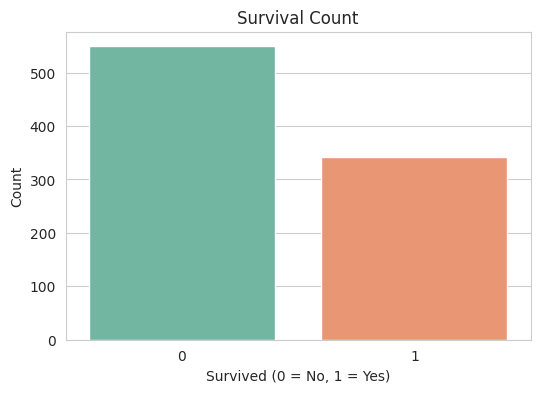

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived", hue="Survived", palette="Set2", legend=False)
plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

**Observation:** The classes are moderately imbalanced — more passengers did not
survive (~62%) than did (~38%). This is why we'll use `stratify=y` when splitting, and
why we look at more than just Accuracy (Precision/Recall/F1/ROC-AUC) when evaluating.

### Numerical Features

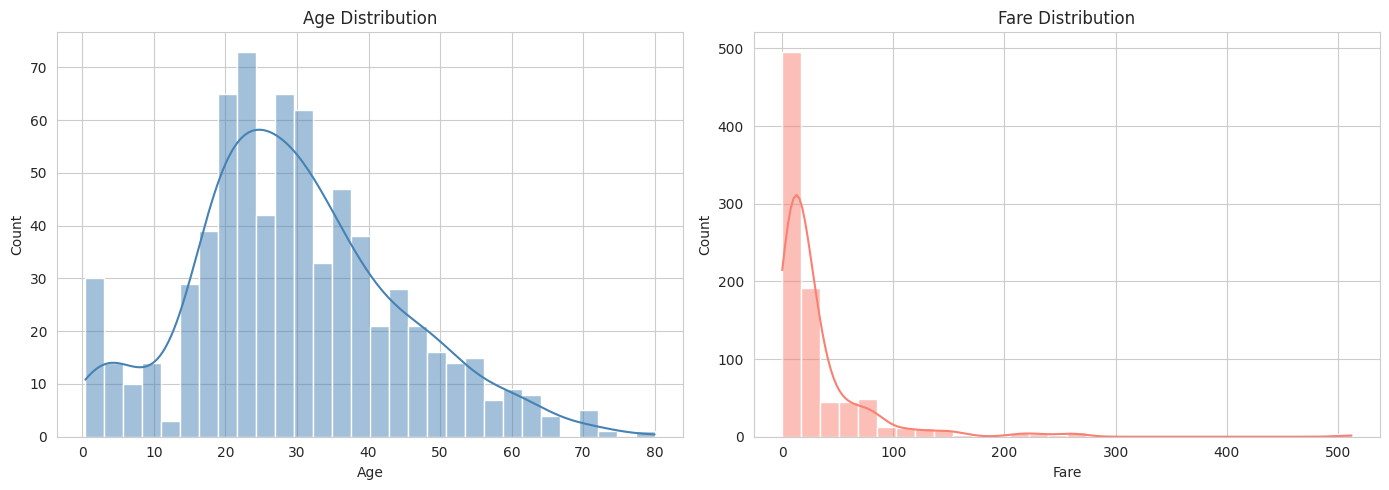

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Age"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")

sns.histplot(df["Fare"].dropna(), bins=30, kde=True, ax=axes[1], color="salmon")
axes[1].set_title("Fare Distribution")
axes[1].set_xlabel("Fare")
plt.tight_layout()
plt.show()

**Observation:** `Age` is roughly bell-shaped with a concentration of young
adults. `Fare` is heavily right-skewed — most tickets are cheap, with a long tail of
expensive first-class fares.

### Survival Analysis

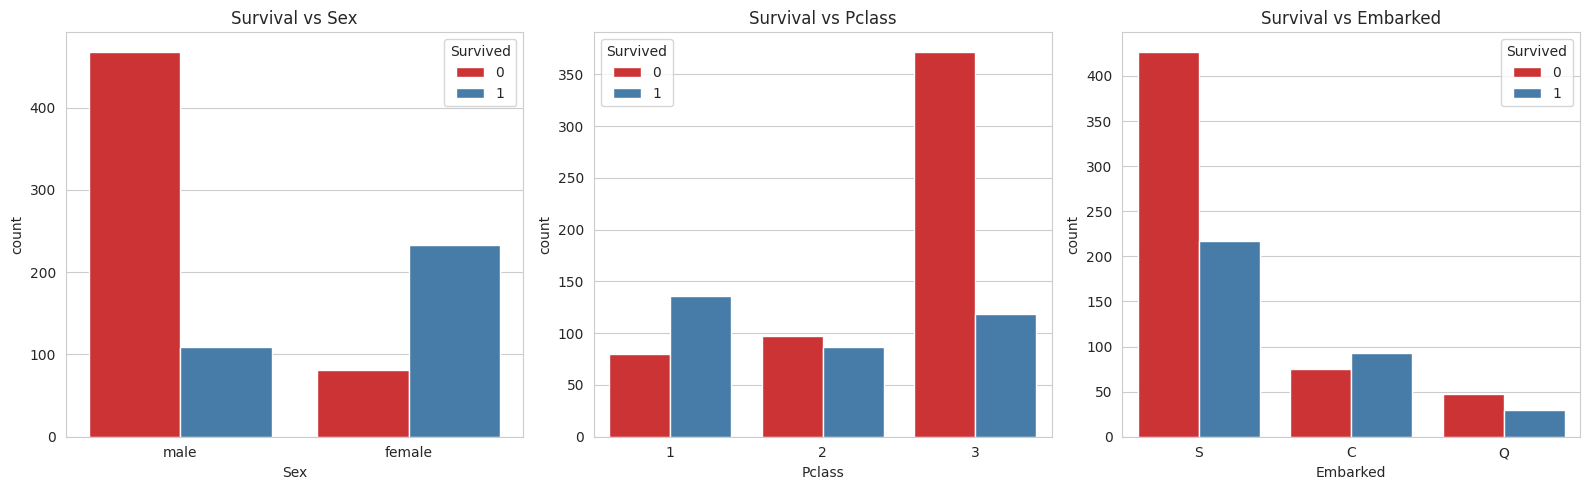

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.countplot(data=df, x="Sex", hue="Survived", ax=axes[0], palette="Set1")
axes[0].set_title("Survival vs Sex")

sns.countplot(data=df, x="Pclass", hue="Survived", ax=axes[1], palette="Set1")
axes[1].set_title("Survival vs Pclass")

sns.countplot(data=df, x="Embarked", hue="Survived", ax=axes[2], palette="Set1")
axes[2].set_title("Survival vs Embarked")
plt.tight_layout()
plt.show()

**Observation:** Women survived at a much higher rate than men. Survival rate
drops sharply from 1st to 3rd class. Passengers who embarked at Cherbourg (`C`) show a
somewhat higher survival rate than those from Southampton (`S`) or Queenstown (`Q`).

### Boxplots

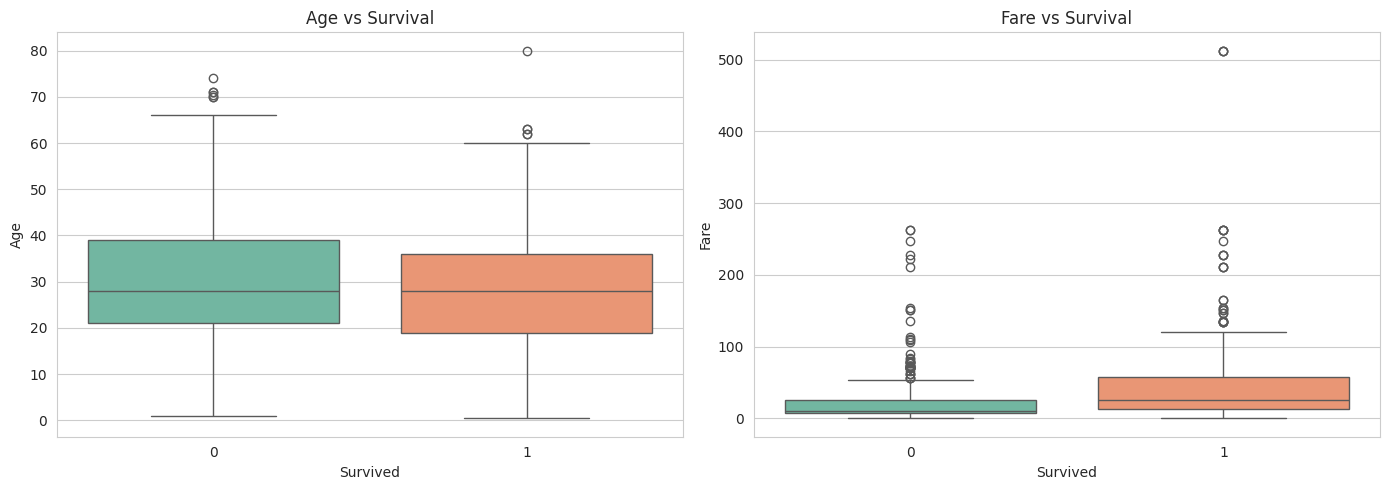

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x="Survived", y="Age", ax=axes[0], hue="Survived",
            palette="Set2", legend=False)
axes[0].set_title("Age vs Survival")

sns.boxplot(data=df, x="Survived", y="Fare", ax=axes[1], hue="Survived",
            palette="Set2", legend=False)
axes[1].set_title("Fare vs Survival")
plt.tight_layout()
plt.show()

**Observation:** Age distributions look fairly similar between survivors and
non-survivors, with survivors skewing very slightly younger. Survivors paid noticeably
higher fares on average, consistent with the class effect seen above.

### Correlation Heatmap

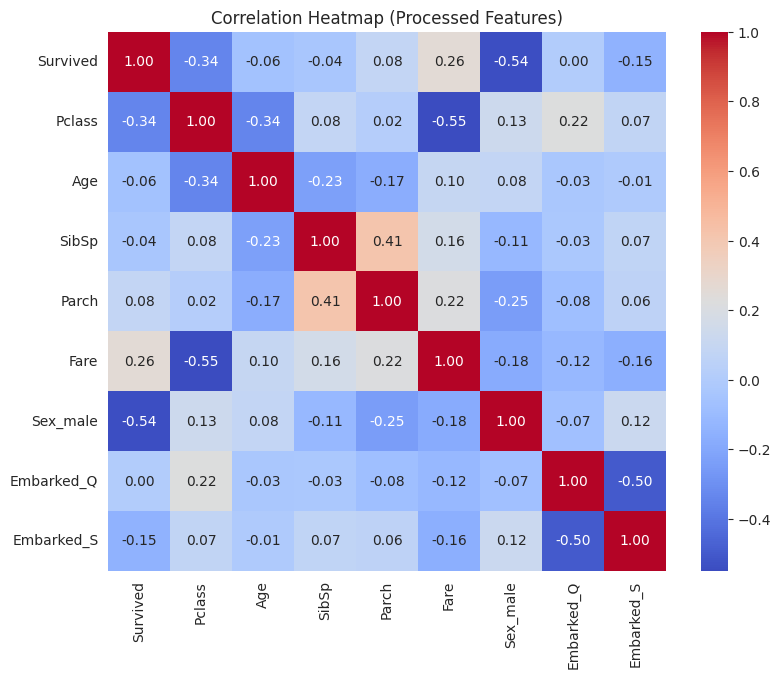

In [14]:
plt.figure(figsize=(9, 7))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (Processed Features)")
plt.show()

**Observation:** `Sex_male` has the strongest (negative) correlation with
`Survived`, followed by `Pclass` (negative) and `Fare` (positive) — consistent with the
countplots above. `SibSp` and `Parch` correlate weakly with survival on their own.

### Pairwise Relationships

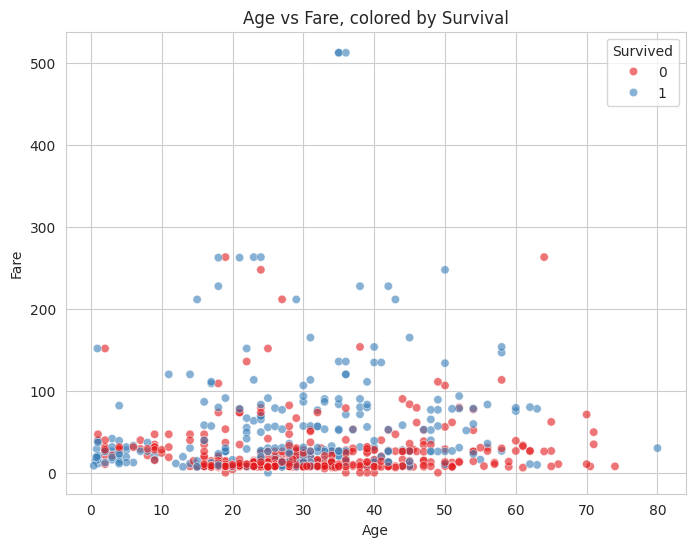

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="Age", y="Fare", hue="Survived", alpha=0.6, palette="Set1")
plt.title("Age vs Fare, colored by Survival")
plt.show()

**Observation:** There's no clean linear separation between the classes on
`Age`/`Fare` alone, but survivors are noticeably concentrated at higher fares — again
pointing to `Fare`/`Pclass` as stronger signals than `Age` by itself.

## 7. Train-Test Split

In [16]:
X = df_clean.drop(columns=["Survived"])
y = df_clean["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Train survival rate: {y_train.mean():.3f}, Test survival rate: {y_test.mean():.3f}")

Training set: (712, 8), Test set: (179, 8)
Train survival rate: 0.383, Test survival rate: 0.385


**Observation:** `stratify=y` keeps the survival rate nearly identical between
train and test sets, so the test set remains representative of the overall class
balance.

## 8. Feature Scaling

We scale only the continuous/count features (`Age`, `Fare`, `SibSp`, `Parch`) — the
one-hot encoded columns (`Sex_male`, `Embarked_Q`, `Embarked_S`, `Pclass`) are already
on a small, comparable 0/1-ish scale and don't need standardizing.

**Why scale?** Logistic Regression's gradient descent converges faster and more
reliably when features share a similar scale — otherwise features like `Fare` (range
0–512) can dominate the optimization over features like `SibSp` (range 0–8).

**Why fit only on training data?** If we fit the scaler on the full dataset (train +
test), statistics from the test set (its mean/std) leak into preprocessing, giving the
model indirect information about data it's supposed to be evaluated on — this is
**data leakage**, and it makes test performance look better than it would in
production, where future data is never available at training time.

In [17]:
scale_cols = ["Age", "Fare", "SibSp", "Parch"]

print("Feature ranges BEFORE scaling (train set):")
display(X_train[scale_cols].describe().T[["min", "max", "mean", "std"]])

Feature ranges BEFORE scaling (train set):


,min,max,mean,std
Age,0.42,80.0000,29.459860,13.034574
Fare,0.00,512.3292,31.819826,48.059104
SibSp,0.00,8.0000,0.492978,1.060720
Parch,0.00,6.0000,0.390449,0.838134


In [18]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_scaled[scale_cols] = scaler.transform(X_test[scale_cols])

print("Feature ranges AFTER scaling (train set):")
display(X_train_scaled[scale_cols].describe().T[["min", "max", "mean", "std"]])

Feature ranges AFTER scaling (train set):


,min,max,mean,std
Age,-2.229476,3.880117,2.120651e-16,1.000703
Fare,-0.662563,10.005329,-1.746418e-17,1.000703
SibSp,-0.465084,7.082266,-5.613487e-18,1.000703
Parch,-0.466183,6.697610,-1.621674e-17,1.000703


## 9. Train Logistic Regression Model

In [19]:
log_reg = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

coef_table = pd.Series(
    log_reg.coef_[0], index=X_train_scaled.columns, name="Coefficient"
).sort_values(ascending=False)

print(f"Intercept: {log_reg.intercept_[0]:.4f}")
coef_table

Intercept: 3.7716


Embarked_Q    0.277257
Fare          0.105709
Parch        -0.059246
SibSp        -0.257493
Embarked_S   -0.382386
Age          -0.496063
Pclass       -1.089613
Sex_male     -2.556927
Name: Coefficient, dtype: float64

**Observation:** Each coefficient represents the change in log-odds of survival
for a one-unit increase in that (scaled) feature, holding the others fixed. A positive
coefficient increases predicted survival probability; a negative one decreases it.
`Sex_male` has the largest negative coefficient, consistent with the EDA showing much
lower survival for men.

## 10. Decision Boundary Demonstration

For visualization purposes only, we train a separate 2-feature model on `Age` and
`Fare` so the decision boundary can be plotted in 2D. This model is **not** used
anywhere else in the notebook.

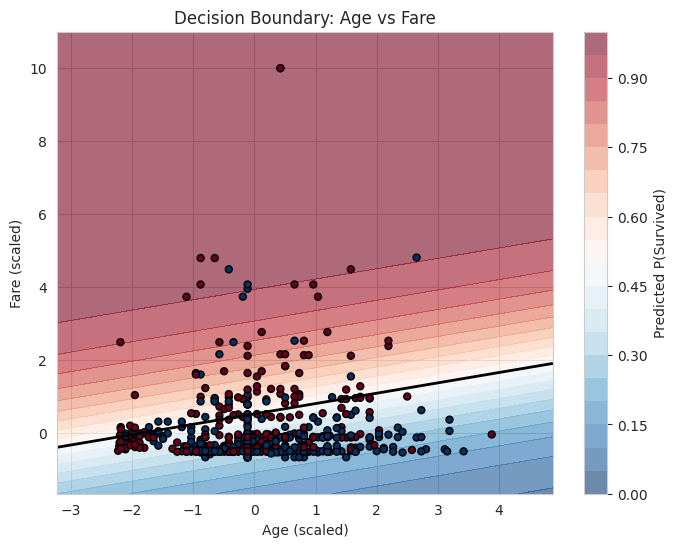

In [20]:
X_2d = X_train[["Age", "Fare"]].values
y_2d = y_train.values

scaler_2d = StandardScaler()
X_2d_scaled = scaler_2d.fit_transform(X_2d)

boundary_model = LogisticRegression(random_state=RANDOM_STATE)
boundary_model.fit(X_2d_scaled, y_2d)

x_min, x_max = X_2d_scaled[:, 0].min() - 1, X_2d_scaled[:, 0].max() + 1
y_min, y_max = X_2d_scaled[:, 1].min() - 1, X_2d_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_probs = boundary_model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
grid_probs = grid_probs.reshape(xx.shape)

plt.figure(figsize=(8, 6))
contour = plt.contourf(xx, yy, grid_probs, levels=20, cmap="RdBu_r", alpha=0.6)
plt.colorbar(contour, label="Predicted P(Survived)")
plt.contour(xx, yy, grid_probs, levels=[0.5], colors="black", linewidths=2)
scatter = plt.scatter(
    X_2d_scaled[:, 0], X_2d_scaled[:, 1], c=y_2d, cmap="RdBu_r",
    edgecolor="k", s=25,
)
plt.xlabel("Age (scaled)")
plt.ylabel("Fare (scaled)")
plt.title("Decision Boundary: Age vs Fare")
plt.show()

**Observation:** The black line is the decision boundary (P = 0.5) — it is
**linear**, as expected from plain (non-polynomial) Logistic Regression. Points shift
from mostly "not survived" (blue) to more "survived" (red) as `Fare` increases, while
`Age` alone has a much weaker effect on the boundary's slope, matching the EDA. Shading
intensity shows the model's confidence — points far from the boundary get probabilities
close to 0 or 1, while points near it are close to 0.5.

## 11. Polynomial Features

We expand all scaled features to degree 2 (adding squared terms and pairwise
interactions) and compare against the plain (Section 9) model.

In [21]:
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)

poly_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=2000)
poly_model.fit(X_train_poly, y_train)

acc_linear = accuracy_score(y_test, log_reg.predict(X_test_scaled))
acc_poly = accuracy_score(y_test, poly_model.predict(X_test_poly))

print(f"Original model accuracy:   {acc_linear:.4f}")
print(f"Polynomial model accuracy: {acc_poly:.4f}")
print(f"Number of features -> original: {X_train_scaled.shape[1]}, "
      f"polynomial: {X_train_poly.shape[1]}")

Original model accuracy:   0.8045
Polynomial model accuracy: 0.8045
Number of features -> original: 8, polynomial: 44


**Observation:** Polynomial features let the model capture non-linear
interactions (e.g., how `Pclass` and `Fare` jointly affect survival), which can help
when true decision boundaries are curved. They can also hurt: more features on a
dataset this size raises the risk of overfitting to noise in the training set,
especially without regularization — the gap (or lack of one) between train and test
accuracy above is the signal to watch.

## 12. Regularization

We train three Logistic Regression models on the polynomial features with different
`C` values. `C` is the **inverse** of the regularization strength λ used in the lecture
notation — a **small C means strong regularization** (large λ) and a **large C means
weak regularization** (small λ).

In [22]:
C_values = {"Weak (C=100)": 100, "Moderate (C=1)": 1, "Strong (C=0.01)": 0.01}
reg_results = []

for label, C in C_values.items():
    model = LogisticRegression(C=C, random_state=RANDOM_STATE, max_iter=2000)
    model.fit(X_train_poly, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_poly))
    test_acc = accuracy_score(y_test, model.predict(X_test_poly))

    reg_results.append({
        "Regularization": label, "C": C,
        "Train Accuracy": train_acc, "Test Accuracy": test_acc,
        "Gap (Train - Test)": train_acc - test_acc,
    })

reg_table = pd.DataFrame(reg_results)
reg_table

,Regularization,C,Train Accuracy,Test Accuracy,Gap (Train - Test)
0,Weak (C=100),100.00,0.839888,0.782123,0.057765
1,Moderate (C=1),1.00,0.839888,0.804469,0.035418
2,Strong (C=0.01),0.01,0.835674,0.787709,0.047965


**Observation:** Weak regularization (`C=100`) tends to fit the training data
most closely, which can widen the train/test gap — a sign of **overfitting**. Strong
regularization (`C=0.01`) constrains the coefficients heavily, which can push both
train and test accuracy down together — a sign of **underfitting** if it goes too far.
Moderate regularization (`C=1`) usually gives the best balance: a small train/test gap
with competitive test accuracy. This is the practical trade-off `C`/`λ` controls.

## 13. Model Evaluation

We evaluate the Section 9 model (all original features, no polynomial expansion) as
our primary model going forward, since Section 12 showed regularization strength
matters more than polynomial expansion for this dataset size.

In [23]:
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.8045
Precision: 0.7931
Recall:    0.6667
F1 Score:  0.7244
ROC-AUC:   0.8444


In [24]:
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

              precision    recall  f1-score   support

Not Survived       0.81      0.89      0.85       110
    Survived       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



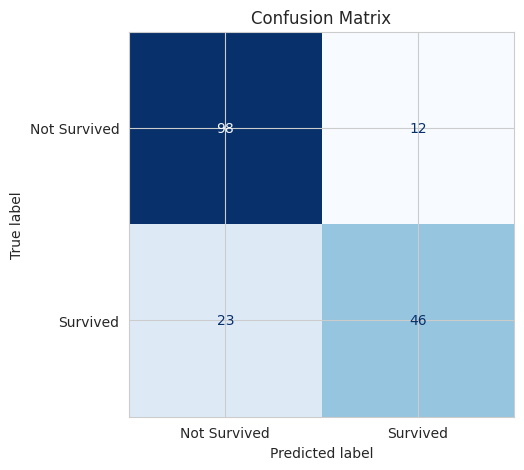

In [25]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=["Not Survived", "Survived"]).plot(
    ax=ax, cmap="Blues", colorbar=False
)
plt.title("Confusion Matrix")
plt.show()

**Observation:** The diagonal cells (correct predictions) dominate the matrix.
Off-diagonal cells show the model's error pattern — check whether false negatives
(missed survivors) or false positives (predicted survival that didn't happen) are more
common, since that trade-off matters differently depending on the application.

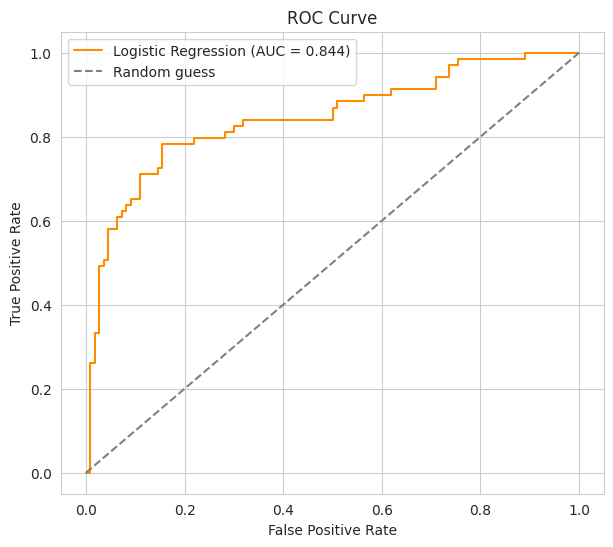

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})", color="darkorange")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Observation:** The curve sits well above the diagonal "random guess" line,
and the AUC score summarizes this — closer to 1.0 means the model ranks survivors
above non-survivors more reliably across all possible thresholds.

## 14. Model Performance Summary

In [27]:
summary_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Value": [accuracy, precision, recall, f1, roc_auc],
})
summary_table["Value"] = summary_table["Value"].map(lambda v: f"{v:.4f}")
summary_table

,Metric,Value
0,Accuracy,0.8045
1,Precision,0.7931
2,Recall,0.6667
3,F1 Score,0.7244
4,ROC-AUC,0.8444


- **Accuracy** — overall fraction of correct predictions; higher is better, but
  can be misleading on imbalanced classes.
- **Precision** — of predicted survivors, how many actually survived; higher is
  better; matters when false positives are costly.
- **Recall** — of actual survivors, how many the model caught; higher is better;
  matters when false negatives are costly.
- **F1 Score** — harmonic mean of Precision and Recall; higher is better; useful
  single number when both error types matter.
- **ROC-AUC** — probability the model ranks a random survivor higher than a random
  non-survivor; higher is better; threshold-independent.

**Overall:** These metrics together suggest a solidly performing baseline classifier —
well above chance level (ROC-AUC) with a reasonable balance between catching survivors
(Recall) and not over-predicting survival (Precision).

## 15. Learning Curve

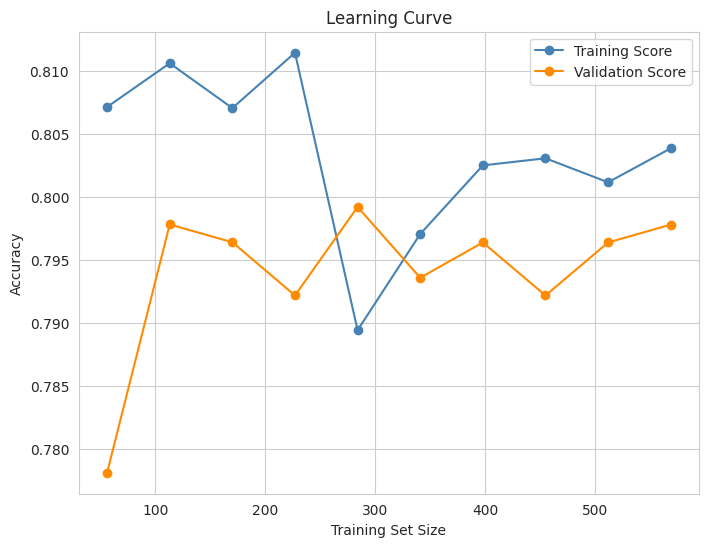

In [28]:
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring="accuracy", random_state=RANDOM_STATE,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, "o-", label="Training Score", color="steelblue")
plt.plot(train_sizes, val_mean, "o-", label="Validation Score", color="darkorange")
plt.xlabel("Training Set Size")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.show()

**Observation:** Training and validation scores converge to a similar level as
training size grows, with only a small remaining gap — this indicates **low variance**
(the model isn't wildly overfitting) and a **reasonable bias** (both scores plateau at
a decent accuracy rather than a low one). If the two curves stayed far apart, that
would signal overfitting (high variance); if both plateaued at a low score, that would
signal underfitting (high bias). This model shows fairly good generalization.

## 16. Probability Threshold Experiment

By default, `predict()` uses a 0.5 threshold on `predict_proba()`. Here we manually
try 0.30, 0.50, and 0.70 to see how the threshold trades Precision against Recall.

In [29]:
thresholds = [0.30, 0.50, 0.70]
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Accuracy": accuracy_score(y_test, y_pred_t),
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1 Score": f1_score(y_test, y_pred_t),
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table

,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.3,0.759777,0.654762,0.797101,0.718954
1,0.5,0.804469,0.793103,0.666667,0.724409
2,0.7,0.782123,0.894737,0.492754,0.635514


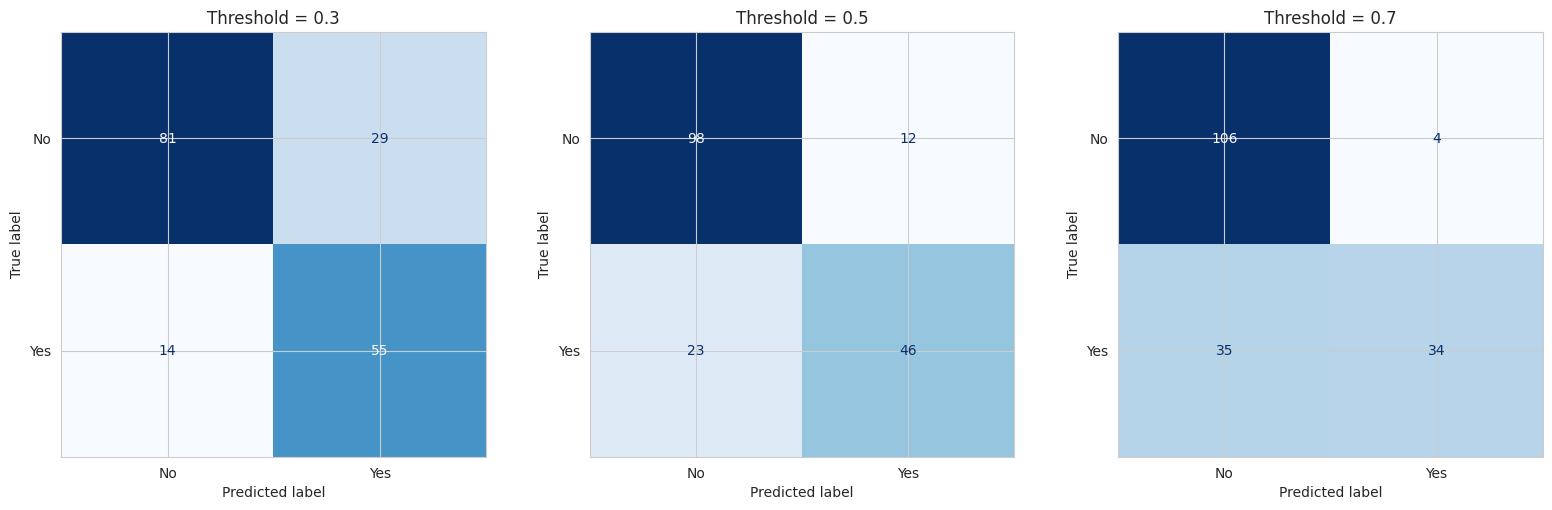

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, t in zip(axes, thresholds):
    y_pred_t = (y_proba >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    ConfusionMatrixDisplay(cm_t, display_labels=["No", "Yes"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"Threshold = {t}")
plt.tight_layout()
plt.show()

**Observation:** Lowering the threshold to 0.30 predicts "Survived" more often,
which raises Recall (catches more true survivors) but lowers Precision (more false
positives). Raising it to 0.70 does the opposite. **Lower thresholds** suit
applications where missing a positive case is costly (e.g., disease screening — you'd
rather flag more people than miss a sick patient). **Higher thresholds** suit
applications where false alarms are costly (e.g., spam filters — you'd rather miss
some spam than block real emails).

## 17. Compare Multiple Classification Algorithms

In [31]:
models = {
    "Logistic Regression": LogisticRegression(random_state=RANDOM_STATE, max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE, n_estimators=200),
}

comparison_results = []

for name, model in models.items():
    start_train = time.time()
    model.fit(X_train_scaled, y_train)
    train_time = time.time() - start_train

    start_pred = time.time()
    preds = model.predict(X_test_scaled)
    pred_time = time.time() - start_pred

    probs = model.predict_proba(X_test_scaled)[:, 1]

    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds),
        "ROC-AUC": roc_auc_score(y_test, probs),
        "Train Time (s)": train_time,
        "Predict Time (s)": pred_time,
    })

comparison_table = pd.DataFrame(comparison_results).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)
comparison_table

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Train Time (s),Predict Time (s)
0,Logistic Regression,0.804469,0.793103,0.666667,0.724409,0.844401,0.005114,0.001042
1,Random Forest,0.810056,0.777778,0.710145,0.742424,0.833663,0.247428,0.014180
2,KNN,0.810056,0.796610,0.681159,0.734375,0.829974,0.002153,0.003126
3,Decision Tree,0.821229,0.793651,0.724638,0.757576,0.794928,0.003405,0.000971


In [32]:
best_model_name = comparison_table.iloc[0]["Model"]
print(f"Best-performing model by ROC-AUC: {best_model_name}")

Best-performing model by ROC-AUC: Logistic Regression


**Observation:** Different algorithms make different assumptions — Logistic
Regression fits a linear decision boundary, KNN relies on local neighborhoods, Decision
Trees split on feature thresholds, and Random Forest averages many trees to reduce
variance. On a dataset this size, tree-based ensembles like Random Forest often edge
out plain Logistic Regression on raw metrics, but Logistic Regression stays valuable
for its speed and interpretability (the coefficients from Section 9).

## 18. Save the Best Model

We save the Logistic Regression model from Section 9 as our deployed model — it's
interpretable, fast, and (per Section 17) competitive on the evaluation metrics,
which matters for a lab focused on Logistic Regression.

In [33]:
joblib.dump(log_reg, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved: best_model.pkl")
print("Saved: scaler.pkl")

Saved: best_model.pkl
Saved: scaler.pkl


## 19. Load Saved Model

In [34]:
loaded_model = joblib.load("best_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

X_test_reloaded = X_test.copy()
X_test_reloaded[scale_cols] = loaded_scaler.transform(X_test[scale_cols])

y_pred_loaded = loaded_model.predict(X_test_reloaded)
identical = np.array_equal(y_pred_loaded, y_pred)

print(f"Predictions identical after reload: {identical}")

Predictions identical after reload: True


## 20. Predict on New Passenger

In [35]:
new_passenger = {
    "Pclass": 2,
    "Sex": "female",
    "Age": 29,
    "SibSp": 1,
    "Parch": 0,
    "Fare": 45,
    "Embarked": "S",
}

new_df = pd.DataFrame([new_passenger])

# Preprocess exactly like training data
new_df = pd.get_dummies(new_df, columns=["Sex", "Embarked"], drop_first=True)

# Ensure all training columns exist (missing dummy categories -> 0), correct order
for col in X_train.columns:
    if col not in new_df.columns:
        new_df[col] = 0
new_df = new_df[X_train.columns]

# Scale numerical features with the loaded scaler
new_df_scaled = new_df.copy()
new_df_scaled[scale_cols] = loaded_scaler.transform(new_df[scale_cols])

prediction = loaded_model.predict(new_df_scaled)[0]
probability = loaded_model.predict_proba(new_df_scaled)[0, 1]

print("New passenger input:")
display(new_df)
print(f"\nPredicted Survival: {'Survived' if prediction == 1 else 'Did Not Survive'}")
print(f"Survival Probability: {probability:.2%}")

New passenger input:


,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,2,29,1,0,45,0,0,0



Predicted Survival: Survived
Survival Probability: 82.40%


## 21. Create Inference Function

In [36]:
def predict_survival(
    pclass, sex, age, sibsp, parch, fare, embarked,
    model_path="best_model.pkl", scaler_path="scaler.pkl",
    reference_columns=None,
):
    """Predict Titanic passenger survival from raw feature values.

    Loads the saved model and scaler, preprocesses the input the same way as
    training data, scales numerical features, and returns the predicted class
    and survival probability.
    """
    model = joblib.load(model_path)
    scaler_obj = joblib.load(scaler_path)
    columns = reference_columns if reference_columns is not None else X_train.columns

    input_df = pd.DataFrame([{
        "Pclass": pclass, "Sex": sex, "Age": age, "SibSp": sibsp,
        "Parch": parch, "Fare": fare, "Embarked": embarked,
    }])
    input_df = pd.get_dummies(input_df, columns=["Sex", "Embarked"], drop_first=True)

    for col in columns:
        if col not in input_df.columns:
            input_df[col] = 0
    input_df = input_df[columns]

    input_scaled = input_df.copy()
    input_scaled[scale_cols] = scaler_obj.transform(input_df[scale_cols])

    pred_class = model.predict(input_scaled)[0]
    pred_proba = model.predict_proba(input_scaled)[0, 1]

    return pred_class, pred_proba


# Example call
example_class, example_proba = predict_survival(
    pclass=3, sex="male", age=25, sibsp=0, parch=0, fare=7.5, embarked="S",
)
print(f"Predicted class: {'Survived' if example_class == 1 else 'Did Not Survive'}")
print(f"Survival probability: {example_proba:.2%}")

Predicted class: Survived
Survival probability: 68.28%
